# UCS420 Lab Assignment 9 — NLP Text Preprocessing
Enter your roll number and name, then run all cells.

In [1]:
ROLL_NO = 1024160106
NAME = "AARAV KUMAR ARORA"

import nltk
for pkg in ["punkt", "punkt_tab", "stopwords", "wordnet", "omw-1.4",
            "averaged_perceptron_tagger", "averaged_perceptron_tagger_eng"]:
    nltk.download(pkg, quiet=True)
assert ROLL_NO > 0 and NAME, "Enter your roll number and name first"

ModuleNotFoundError: No module named 'nltk'

### Dataset generator — do not modify

In [ ]:
import random, hashlib
import pandas as pd

def generate_dataset(roll_no):
    """Return (DataFrame of tickets, focus ticket IDs, fingerprint) for a roll number. Do not modify."""
    rng = random.Random(int(roll_no))

    subjects = [("LMS", ["LMS", "lms"]), ("Wi-Fi", ["Wi-Fi", "WiFi", "wifi"]), ("VPN", ["VPN"]),
                ("email", ["email", "e-mail"]), ("password", ["password"]), ("portal", ["student portal"]),
                ("projector", ["projector"]), ("laptop", ["laptop"]), ("MATLAB", ["MATLAB", "Matlab"]),
                ("Python", ["Python"]), ("printer", ["printer"]), ("server", ["server"])]
    actions = ["is not working", "keeps disconnecting", "failed to open", "is running slowly",
               "crashes while opening", "stopped responding", "is showing an error", "was working yesterday",
               "has stopped syncing", "keeps asking for login"]
    user_actions = ["cannot access", "can't open", "couldn't connect to", "am unable to use",
                    "tried restarting", "was locked out of", "keep getting logged out of", "reinstalled"]
    contexts = ["after resetting my password", "during the lab", "on my laptop", "since yesterday",
                "after the latest update", "when I use mobile hotspot", "before the assignment deadline",
                "while uploading the file", "after restarting the system", "when connected to campus Wi-Fi"]
    endings = ["Please help.", "Can you check this?", "I have tried several times!", "It worked yesterday.",
               "I don't know what changed.", "The same problem occurs again.", "Is there another solution?",
               "It works on another computer.", "This is urgent.", "Please resolve it."]
    challenges = {
        "negation": ["The Wi-Fi works, but the VPN doesn't.", "Why isn't the portal opening?",
                     "I can't login and I didn't change anything.", "It's not the laptop; it's the server.",
                     "Nothing works and nobody has replied.", "The printer won't print; it isn't jammed."],
        "numbers": ["Python 3.12 was installed yesterday.", "The file is 95.5% uploaded.",
                    "Error code 0x80070005 appears.", "I need Windows 11 by 5.30 p.m. today.",
                    "Only 2 of 30 PCs boot after 3.5 hours.", "Version 2.0.1 crashes at 99%."],
        "identifiers": ["Email me at helpdesk@university.edu.", "See https://lms.thapar.edu/help for details.",
                        "My roll no. is 1023-03-021.", "Ticket #4521 is still open.",
                        "Call me on +91 98765 43210 or 0175-239-3201.",
                        "Write to it.helpdesk@thapar.edu or visit www.thapar.edu/it."],
        "punctuation": ["I tried again... still no response!!!", "The LMS says 'Not Submitted'.",
                        "Dr. Rao's lab PC (No. 14) is down.", "Is it fixed?? Pls reply ASAP :(",
                        "The state-of-the-art lab (Lab-3) is closed.", "Re-installing didn't help; log-in still fails!"],
    }

    tickets = []
    for _ in range(8 + int(roll_no) % 5):
        _, variants = rng.choice(subjects)
        s = rng.choice(variants)
        template = rng.randrange(3)
        if template == 0:
            text = f"{s} {rng.choice(actions)} {rng.choice(contexts)}. {rng.choice(endings)}"
        elif template == 1:
            text = f"I {rng.choice(user_actions)} the {s} {rng.choice(contexts)}. {rng.choice(endings)}"
        else:
            text = f"The {s} {rng.choice(actions)}. {rng.choice(endings)}"
        tickets.append(text[0].upper() + text[1:])
    for category in ["negation", "numbers", "identifiers", "punctuation"]:
        tickets.append(rng.choice(challenges[category]))
    rng.shuffle(tickets)

    df = pd.DataFrame({"Ticket_ID": [f"T{i + 1:02d}" for i in range(len(tickets))], "Ticket_Text": tickets})
    focus = [f"T{i:02d}" for i in sorted(rng.sample(range(1, len(tickets) + 1), 2))]
    fingerprint = hashlib.md5(("|".join(tickets) + str(int(roll_no))).encode()).hexdigest()[:8].upper()
    return df, focus, fingerprint

### Preprocessing pipeline — do not modify

In [ ]:
import string
from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.corpus import stopwords

STOP = set(stopwords.words("english"))

def is_punct(token):
    """A token is punctuation if EVERY character in it is in string.punctuation (e.g. '.', '...', '``', "''")."""
    return all(ch in string.punctuation for ch in token)

def process_ticket(text):
    """The official pipeline. Returns sentences, lowercase tokens, punctuation, stopwords and final tokens."""
    sentences = sent_tokenize(text)
    tokens = [t.lower() for s in sentences for t in word_tokenize(s)]
    punct = [t for t in tokens if is_punct(t)]
    stops = [t for t in tokens if t in STOP]
    final = [t for t in tokens if not is_punct(t) and t not in STOP]
    return {"sentences": sentences, "tokens": tokens, "punct": punct, "stops": stops, "final": final}

In [ ]:
df, FOCUS, FINGERPRINT = generate_dataset(ROLL_NO)
print(f"Roll number: {ROLL_NO}   Name: {NAME}   Fingerprint: {FINGERPRINT}   Tickets: {len(df)}\n")
print(df.to_string(index=False))
df.to_csv(f"{ROLL_NO}_generated_dataset.csv", index=False)

Roll number: 1024160106   Name: AARAV KUMAR ARORA   Fingerprint: 2CF9FD89   Tickets: 13

Ticket_ID                                                                                      Ticket_Text
      T01                  I tried restarting the VPN after the latest update. I have tried several times!
      T02                                        The laptop failed to open. The same problem occurs again.
      T03                                    The printer crashes while opening. I don't know what changed.
      T04                                                                      My roll no. is 1023-03-021.
      T05              Python is running slowly before the assignment deadline. Is there another solution?
      T06   I keep getting logged out of the student portal since yesterday. It works on another computer.
      T07 Student portal keeps asking for login when connected to campus Wi-Fi. Is there another solution?
      T08                                              

---
## Q1. Preprocessing pipeline
Run process_ticket() on every ticket and show one table with, per ticket: sentences, tokens, punctuation tokens, stopwords, unique tokens and final tokens, plus a TOTAL row.

In [ ]:
results = [process_ticket(t) for t in df["Ticket_Text"]]

q1 = pd.DataFrame({
    "Ticket_ID": df["Ticket_ID"],
    "Sentences": [len(r["sentences"]) for r in results],
    "Tokens": [len(r["tokens"]) for r in results],
    "Punctuation": [len(r["punct"]) for r in results],
    "Stopwords": [len(r["stops"]) for r in results],
    "Unique_Tokens": [len(set(r["tokens"])) for r in results],
    "Final_Tokens": [len(r["final"]) for r in results],
})
q1.loc[len(q1)] = ["TOTAL"] + q1.drop(columns="Ticket_ID").sum().astype(int).tolist()
print(q1.to_string(index=False))

sel = int(df.index[df["Ticket_ID"] == FOCUS[0]][0])
print(f"\nSelected ticket: {FOCUS[0]}")
print("Text           :", df["Ticket_Text"][sel])
print("Tokens         :", results[sel]["tokens"])
print("Punctuation    :", results[sel]["punct"])
print("Stopwords      :", results[sel]["stops"])
print("Final tokens   :", results[sel]["final"])

odd = sorted({t for r in results for t in r["final"] if not t.isalpha()})
print("\nFinal tokens that are not plain words:", odd)

Ticket_ID  Sentences  Tokens  Punctuation  Stopwords  Unique_Tokens  Final_Tokens
      T01          2      16            2          6             13             8
      T02          2      12            2          5             10             5
      T03          2      13            2          5             12             6
      T04          2       7            2          3              6             2
      T05          2      14            2          5             13             7
      T06          2      18            2          6             17            10
      T07          2      17            2          5             17            10
      T08          1       7            1          3              7             3
      T09          2      12            2          5             12             5
      T10          1       6            1          1              6             4
      T11          2      17            2          6             16             9
      T12       

**Observe:** Which final tokens in your data are not real words (e.g. n't, 's, ca)? Where do they come from?

*Your answer:* The final tokens that are not real words are n't, 's, dr., 3.12, 14, 1023-03-021 and wi-fi. n't and 's come from word_tokenize splitting contractions and possessives (isn't becomes is + n't, Rao's becomes rao + 's); the stopword list contains is but not n't or 's, so these pieces survive as final tokens. dr. keeps its period, so is_punct does not remove it. The numbers, the roll number and the hyphenated Wi-Fi are kept as single tokens because they contain characters that are not stopwords or pure punctuation.

---
## Q2. Regular expressions
On your raw tickets, use re.findall to extract: words longer than 5 letters; all numbers (keep 95.5 and 2.0.1 whole); capitalized words; words starting with a vowel. Then use re.sub to replace emails with <EMAIL>, URLs with <URL> and phone numbers with <PHONE>. Your patterns must also work on TEST_LINES (given in the notebook).

In [ ]:
TEST_LINES = [
    "Mail it.helpdesk@thapar.edu or a.b-c@dept.univ.ac.in; visit https://lms.thapar.edu/help or www.thapar.edu/it.",
    "Call +91 98765 43210, +91-98765-43210 or 0175-239-3201. Version 2.0.1 is 95.5% done; fee Rs 1,250.",
    "The state-of-the-art lab isn't open; log-in at 5.30 p.m. didn't work.",
]

import re
from collections import Counter

LONG_WORDS = r"(?<![\w-])[A-Za-z]{6,}(?![\w-]|['\u2019]\w)"
NUMBERS = r"(?<![\w.])\d+(?:,\d{3})*(?:\.\d+)*(?!\w)"
CAPITALIZED = r"(?<![\w-])[A-Z][A-Za-z]*(?:['\u2019-][A-Za-z]+)*(?![\w-])"
VOWEL_WORDS = r"(?<![\w-])[AEIOUaeiou][A-Za-z]*(?:['\u2019-][A-Za-z]+)*(?![\w-])"

EMAIL = r"\b[\w.+-]+@[\w-]+(?:\.[\w-]+)+\b"
URL = r"(?:https?://|www\.)[^\s<>\"']*[^\s<>\"'.,;:!?)]"
PHONE = (r"(?<![\w.-])(?:\+\d{1,3}[\s.-]?)?"
         r"(?:\(\d{2,4}\)[\s.-]?\d{3,4}[\s.-]?\d{3,4}"
         r"|\d{2,5}[\s.-]\d{3,5}(?:[\s.-]\d{3,5})?"
         r"|\d{10})(?![\w])")

def blank_ids(text):
    text = re.sub(URL, " ", text)
    text = re.sub(EMAIL, " ", text)
    return re.sub(PHONE, " ", text)

def extract(text):
    text = blank_ids(text)
    return {
        "long_words": re.findall(LONG_WORDS, text),
        "numbers": re.findall(NUMBERS, text),
        "capitalized": re.findall(CAPITALIZED, text),
        "vowel_words": re.findall(VOWEL_WORDS, text),
    }

def mask(text):
    text = re.sub(URL, "<URL>", text)
    text = re.sub(EMAIL, "<EMAIL>", text)
    text = re.sub(PHONE, "<PHONE>", text)
    return text

pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 250)

ticket_ext = pd.DataFrame([extract(t) for t in df["Ticket_Text"]])
ticket_ext.insert(0, "Ticket_ID", df["Ticket_ID"])
print("findall on tickets\n")
print(ticket_ext.to_string(index=False))

test_ext = pd.DataFrame([extract(t) for t in TEST_LINES])
test_ext.insert(0, "Line", range(1, len(TEST_LINES) + 1))
print("\nfindall on TEST_LINES\n")
print(test_ext.to_string(index=False))

print("\nre.sub on TEST_LINES\n")
for line in TEST_LINES:
    print("Before:", line)
    print("After :", mask(line), "\n")

print("re.sub on tickets (changed tickets only)\n")
for tid, text in zip(df["Ticket_ID"], df["Ticket_Text"]):
    masked = mask(text)
    if masked != text:
        print(tid, "|", text)
        print("    ->", masked)

cap_total = sum(len(re.findall(CAPITALIZED, t)) for t in df["Ticket_Text"])
cap_initial = sum(1 for t in df["Ticket_Text"] for s in sent_tokenize(t) if re.match(CAPITALIZED, s))
print(f"\nCapitalized words: {cap_total}, of which sentence-initial: {cap_initial}")

findall on tickets

Ticket_ID                                                                  long_words         numbers          capitalized                                  vowel_words
      T01                                       [restarting, latest, update, several]              []          [I, VPN, I]                        [I, after, update, I]
      T02                                           [laptop, failed, problem, occurs]              []           [The, The]                        [open, occurs, again]
      T03                                        [printer, crashes, opening, changed]              []             [The, I]                                 [opening, I]
      T04                                                                          [] [1023, 03, 021]                 [My]                                         [is]
      T05  [Python, running, slowly, before, assignment, deadline, another, solution]              []         [Python, Is]                [i

**Observe:** How many of your capitalized words are capitalized only because they start a sentence?

*Your answer:* There are 28 capitalized words, and 22 of them are capitalized only because they start a sentence (The, It, Is, Why, This, I, ...). The remaining 6 are genuinely capitalized: VPN, Wi-Fi (twice), Rao's, PC and No.

---
## Q3. Custom tokenizer
Write my_tokenize(text) with one RegexpTokenizer pattern that keeps contractions (isn't), hyphenated words (Wi-Fi, state-of-the-art), decimals and versions (95.5, 2.0.1), emails, URLs and phone numbers as single tokens. Run it on TEST_LINES and on your tickets, and compare with word_tokenize.

In [ ]:
from nltk.tokenize import RegexpTokenizer

TOKEN_PATTERN = (
    r"(?:https?://|www\.)[^\s<>\"']*[^\s<>\"'.,;:!?)]"
    r"|\b[\w.+-]+@[\w-]+(?:\.[\w-]+)+\b"
    r"|(?<![\w.-])(?:\+\d{1,3}[\s.-]?)?"
    r"(?:\(\d{2,4}\)[\s.-]?\d{3,4}[\s.-]?\d{3,4}"
    r"|\d{2,5}[\s.-]\d{3,5}(?:[\s.-]\d{3,5})?"
    r"|\d{10})(?![\w])"
    r"|\b\d{1,3}(?:,\d{3})+(?:\.\d+)?\b"
    r"|\b[vV]?\d+(?:\.\d+)+\b"
    r"|\b(?:[A-Za-z]\.){2,}"
    r"|\w+(?:[-'\u2019]\w+)*"
    r"|[^\w\s]"
)

_tokenizer = RegexpTokenizer(TOKEN_PATTERN)

def my_tokenize(text):
    return _tokenizer.tokenize(text)

def compare(text):
    mine = my_tokenize(text)
    ref = word_tokenize(text)
    return mine, ref, [t for t in mine if t not in ref], [t for t in ref if t not in mine]

print("TEST_LINES\n")
for i, line in enumerate(TEST_LINES, 1):
    mine, ref, only_mine, only_ref = compare(line)
    print(f"Line {i}: {line}")
    print("my_tokenize  :", mine)
    print("word_tokenize:", ref)
    print("only in my_tokenize  :", only_mine)
    print("only in word_tokenize:", only_ref, "\n")

print("Tickets\n")
differing = 0
for tid, text in zip(df["Ticket_ID"], df["Ticket_Text"]):
    mine, ref, only_mine, only_ref = compare(text)
    if mine != ref:
        differing += 1
        print(f"{tid}: {text}")
        print("   only in my_tokenize  :", only_mine)
        print("   only in word_tokenize:", only_ref)
print(f"\nTickets tokenized differently: {differing} of {len(df)}")

CATEGORIES = {
    "email address": (r"@", "word_tokenize treats '@' as separate punctuation and breaks the address apart; my_tokenize has an email alternative so it stays one token."),
    "URL": (r"^(?:https?://|www\.)", "word_tokenize splits at ':' and '/' so the URL is fragmented; my_tokenize matches the whole URL as one token."),
    "phone number": (r"^\+?\(?\d[\d\s().-]{7,}\d$", "word_tokenize splits on whitespace, so a number with spaces becomes several tokens; my_tokenize has a phone alternative."),
    "decimal / version": (r"^[vV]?\d+(?:\.\d+)+$", "my_tokenize matches digit groups joined by dots as one token (95.5, 2.0.1, 3.12)."),
    "hyphenated word": (r"\w-\w", "my_tokenize joins word parts with hyphens (Wi-Fi, state-of-the-art, 1023-03-021); word_tokenize may keep or split these differently."),
    "contraction": (r"['\u2019]", "word_tokenize follows Penn Treebank and splits isn't into is + n't; my_tokenize keeps isn't whole."),
    "thousands number": (r"^\d{1,3}(?:,\d{3})+", "my_tokenize keeps 1,250 whole through an explicit rule."),
}

REF_CATEGORIES = {
    "abbreviation with period": (r"^[A-Za-z]{1,3}\.$", "word_tokenize keeps the period attached to abbreviations such as Dr. because it only splits a period at the end of the text; my_tokenize emits the word and the period separately."),
    "abbreviation": (r"^(?:[A-Za-z]\.){2,}$", "word_tokenize keeps abbreviations like p.m. as one token; a tokenizer without an abbreviation rule would split them."),
    "repeated punctuation": (r"^(?:\.{2,}|[!?]{2,})$", "word_tokenize keeps runs such as ... as one token; my_tokenize emits each punctuation character separately."),
}

pool = list(TEST_LINES) + list(df["Ticket_Text"])
seen = {}
for text in pool:
    mine, ref, only_mine, only_ref = compare(text)
    for tok in only_mine:
        for name, (pat, why) in CATEGORIES.items():
            if re.search(pat, tok):
                if name not in seen:
                    seen[name] = (tok, word_tokenize(tok), why)
                break
    for tok in only_ref:
        for name, (pat, why) in REF_CATEGORIES.items():
            if re.search(pat, tok) and name not in seen:
                seen[name] = (tok, my_tokenize(tok), why)

print("\nDifferences between my_tokenize and word_tokenize\n")
for k, (name, (tok, other, why)) in enumerate(seen.items(), 1):
    print(f"{k}. {name}: example token {[tok]} | other tokenizer output -> {other}")
    print("   ", why)

only_ref_counter = Counter(t for text in pool for t in compare(text)[3])
print("\nTokens produced only by word_tokenize:", only_ref_counter.most_common(10))

TEST_LINES

Line 1: Mail it.helpdesk@thapar.edu or a.b-c@dept.univ.ac.in; visit https://lms.thapar.edu/help or www.thapar.edu/it.
my_tokenize  : ['Mail', 'it.helpdesk@thapar.edu', 'or', 'a.b-c@dept.univ.ac.in', ';', 'visit', 'https://lms.thapar.edu/help', 'or', 'www.thapar.edu/it', '.']
word_tokenize: ['Mail', 'it.helpdesk', '@', 'thapar.edu', 'or', 'a.b-c', '@', 'dept.univ.ac.in', ';', 'visit', 'https', ':', '//lms.thapar.edu/help', 'or', 'www.thapar.edu/it', '.']
only in my_tokenize  : ['it.helpdesk@thapar.edu', 'a.b-c@dept.univ.ac.in', 'https://lms.thapar.edu/help']
only in word_tokenize: ['it.helpdesk', '@', 'thapar.edu', 'a.b-c', '@', 'dept.univ.ac.in', 'https', ':', '//lms.thapar.edu/help'] 

Line 2: Call +91 98765 43210, +91-98765-43210 or 0175-239-3201. Version 2.0.1 is 95.5% done; fee Rs 1,250.
my_tokenize  : ['Call', '+91 98765 43210', ',', '+91-98765-43210', 'or', '0175-239-3201', '.', 'Version', '2.0.1', 'is', '95.5', '%', 'done', ';', 'fee', 'Rs', '1,250', '.']
word_tokeni

**Observe:** How many of your tickets are tokenized differently by my_tokenize and word_tokenize?

*Your answer:* 3 of 13 tickets are tokenized differently. T03 (don't) and T08 (isn't) differ because word_tokenize splits contractions into do + n't and is + n't while my_tokenize keeps them whole. T12 (Dr. Rao's lab PC (No. 14) is down.) differs because word_tokenize keeps Dr. with its period and splits Rao's into Rao + 's, while my_tokenize gives Dr + . and keeps Rao's whole.

---
## Q4. Stemming and lemmatization
On your unique final tokens, compare PorterStemmer, LancasterStemmer, a RegexpStemmer with a suffix rule you choose after looking at your own words, and WordNetLemmatizer with POS tags from nltk.pos_tag. Show a table of the words where the outputs differ.

In [ ]:
from nltk.stem import PorterStemmer, LancasterStemmer, RegexpStemmer, WordNetLemmatizer
from nltk.corpus import wordnet

tag_votes = {}
for r in results:
    keep = set(r["final"])
    for w, tg in nltk.pos_tag(r["tokens"]):
        if w in keep:
            tag_votes.setdefault(w, Counter())[tg] += 1
UNIQUE_FINAL = sorted(tag_votes)

def wn_pos(tag):
    return {"J": wordnet.ADJ, "V": wordnet.VERB, "N": wordnet.NOUN, "R": wordnet.ADV}.get(tag[0], wordnet.NOUN)

CANDIDATES = ["ing", "ed", "ly", "ment", "ion", "es"]
suffix_words = {c: [w for w in UNIQUE_FINAL if w.endswith(c) and len(w) >= len(c) + 3] for c in CANDIDATES}
SUFFIX = max(CANDIDATES, key=lambda c: len(suffix_words[c]))
print("Suffix candidates and matching words from this dataset:")
for c in CANDIDATES:
    print(f"  {c}: {suffix_words[c]}")
print(f"\nChosen suffix: '{SUFFIX}'")

porter = PorterStemmer()
lancaster = LancasterStemmer()
regexp = RegexpStemmer(SUFFIX + "$", min=4)
lemmatizer = WordNetLemmatizer()

examples = ", ".join(f"{w} -> {regexp.stem(w)}" for w in suffix_words[SUFFIX][:4])
print(f"Justification: '{SUFFIX}' ends {len(suffix_words[SUFFIX])} unique final tokens in this dataset "
      f"({', '.join(suffix_words[SUFFIX][:4])}), more than any other candidate suffix, so one rule covers the most words. "
      f"Resulting stems: {examples}. Limitation: the rule does not undo doubled consonants.")

rows = []
for w in UNIQUE_FINAL:
    tag = tag_votes[w].most_common(1)[0][0]
    rows.append({
        "word": w,
        "pos_tag": tag,
        "porter": porter.stem(w),
        "lancaster": lancaster.stem(w),
        "regexp": regexp.stem(w),
        "lemma": lemmatizer.lemmatize(w, wn_pos(tag)),
    })
stem_df = pd.DataFrame(rows)
diff_df = stem_df[stem_df[["porter", "lancaster", "regexp", "lemma"]].nunique(axis=1) > 1]
print(f"\nUnique final tokens: {len(stem_df)}, words where outputs differ: {len(diff_df)}\n")
print(diff_df.to_string(index=False))

def collisions(col):
    groups = {}
    for _, row in stem_df.iterrows():
        groups.setdefault(row[col], set()).add((row["word"], row["lemma"]))
    return {s: g for s, g in groups.items() if len({l for _, l in g}) > 1}

over, over_col = {}, None
for col in ("porter", "lancaster"):
    over = collisions(col)
    if over:
        over_col = col
        break
if over:
    stem, g = next(iter(over.items()))
    over_msg = f"{over_col} stem '{stem}' <- {sorted(w for w, _ in g)} (different lemmas collapsed to one stem)"
else:
    longest = max(rows, key=lambda r: len(r["word"]) - len(r["lancaster"]))
    over_msg = f"'{longest['word']}' -> Lancaster '{longest['lancaster']}' (cut to {len(longest['lancaster'])} letters, over-aggressive)"
print("\nOver-stemming example:")
print(f"  {over_msg}")

by_lemma = {}
for _, row in stem_df.iterrows():
    by_lemma.setdefault(row["lemma"], []).append((row["word"], row["porter"]))
under = {l: v for l, v in by_lemma.items() if len({s for _, s in v}) > 1}
print("\nUnder-stemming example:")
if under:
    lemma, v = next(iter(under.items()))
    print(f"  lemma '{lemma}' <- {v}")
else:
    pair = next(((a, b) for a in UNIQUE_FINAL for b in UNIQUE_FINAL
                 if a < b and a[:5] == b[:5] and porter.stem(a) != porter.stem(b)), None)
    unchanged = next((r for r in rows if r["regexp"] == r["word"] and r["porter"] == r["lemma"] and r["porter"] != r["word"]), None)
    if pair:
        print(f"  '{pair[0]}' -> '{porter.stem(pair[0])}' but '{pair[1]}' -> '{porter.stem(pair[1])}' although they share a root")
    elif unchanged:
        print(f"  Regexp stemmer leaves '{unchanged['word']}' unchanged while Porter gives '{unchanged['porter']}'")
    else:
        print("  none found in this dataset")

Suffix candidates and matching words from this dataset:
  ing: ['asking', 'getting', 'opening', 'restarting', 'running', 'showing', 'working']
  ed: ['changed', 'connected', 'failed', 'installed', 'logged', 'tried']
  ly: ['slowly']
  ment: ['assignment']
  ion: ['solution']
  es: ['crashes', 'times']

Chosen suffix: 'ing'
Justification: 'ing' ends 7 unique final tokens in this dataset (asking, getting, opening, restarting), more than any other candidate suffix, so one rule covers the most words. Resulting stems: asking -> ask, getting -> gett, opening -> open, restarting -> restart. Limitation: the rule does not undo doubled consonants.



Unique final tokens: 55, words where outputs differ: 34

      word pos_tag  porter lancaster     regexp      lemma
   another      DT   anoth     anoth    another    another
assignment      JJ  assign    assign assignment assignment
    campus      VB   campu      camp     campus     campus
   changed     VBD   chang     chang    changed     change
  computer      NN  comput    comput   computer   computer
 connected     VBN connect   connect  connected    connect
   crashes     NNS   crash     crash    crashes      crash
  deadline      NN deadlin   deadlin   deadline   deadline
     error      NN   error        er      error      error
    failed     VBD    fail      fail     failed       fail
   getting     VBG     get       get       gett        get
 installed     VBN  instal    instal  installed     instal
     keeps     NNS    keep      keep      keeps       keep
    latest     JJS  latest    latest     latest       late
    logged     VBD     log       log     logged        lo

**Observe:** Give one over-stemming and one under-stemming example from your table.

*Your answer:* Over-stemming: Lancaster reduces opening and open to op, error to er and urgent to urg, and Porter reduces several to sever; the stems lose the meaning of the word. Under-stemming: the Regexp stemmer, which only strips ing, leaves connected, changed, failed, crashes and times unchanged although Porter reduces them to connect, chang, fail, crash and time, so related forms are not conflated.

---
## Q5. Corpus statistics
Compute tokens, unique tokens and TTR for S1 (all tokens), S2 (no punctuation), S3 (final tokens) and S4 (S3 after Porter). Print the top 10 words of S1 and S3, plot log(rank) vs log(frequency) for S3, and print the top 5 bigrams of S1 and S3.

Set  Total_Tokens  Unique_Tokens    TTR
 S1           166             87 0.5241
 S2           140             82 0.5857
 S3            81             55 0.6790
 S4            81             52 0.6420

Top 10 words of S1
   word  freq
      .    19
    the    10
     is    10
      i     5
another     4
 portal     4
  tried     3
     to     3
      ?     3
student     3

Top 10 words of S3
   word  freq
another     4
 portal     4
  tried     3
student     3
    vpn     2
several     2
  times     2
opening     2
    n't     2
 python     2


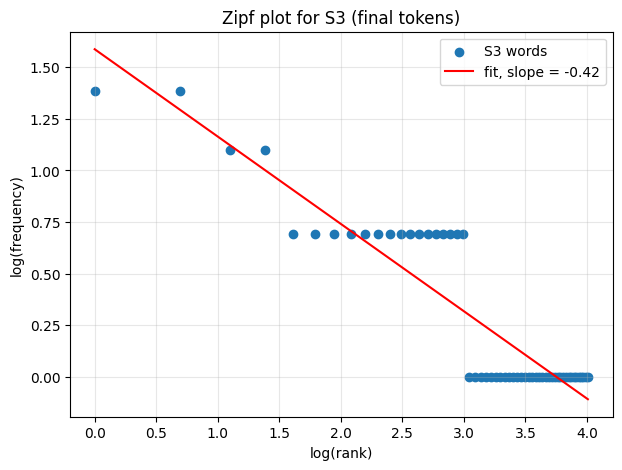

Fitted slope: -0.423

Top 5 bigrams of S1
  ('.', 'i'): 3
  ('.', 'is'): 3
  ('student', 'portal'): 3
  ('i', 'have'): 2
  ('have', 'tried'): 2

Top 5 bigrams of S3
  ('student', 'portal'): 3
  ('tried', 'several'): 2
  ('several', 'times'): 2
  ('assignment', 'deadline'): 2
  ('another', 'solution'): 2

TTR S1=0.5241, S2=0.5857, S3=0.679, S4=0.642


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from nltk import bigrams

S1_by = [r["tokens"] for r in results]
S3_by = [r["final"] for r in results]
S1 = [t for toks in S1_by for t in toks]
S2 = [t for t in S1 if not is_punct(t)]
S3 = [t for toks in S3_by for t in toks]
S4 = [porter.stem(t) for t in S3]

def stats(tokens):
    total, unique = len(tokens), len(set(tokens))
    return total, unique, unique / total

stat_df = pd.DataFrame(
    [(name,) + stats(seq) for name, seq in [("S1", S1), ("S2", S2), ("S3", S3), ("S4", S4)]],
    columns=["Set", "Total_Tokens", "Unique_Tokens", "TTR"],
)
stat_df["TTR"] = stat_df["TTR"].round(4)
print(stat_df.to_string(index=False))

print("\nTop 10 words of S1")
print(pd.DataFrame(Counter(S1).most_common(10), columns=["word", "freq"]).to_string(index=False))
print("\nTop 10 words of S3")
print(pd.DataFrame(Counter(S3).most_common(10), columns=["word", "freq"]).to_string(index=False))

freqs = np.array(sorted(Counter(S3).values(), reverse=True))
ranks = np.arange(1, len(freqs) + 1)
slope, intercept = np.polyfit(np.log(ranks), np.log(freqs), 1)
plt.figure(figsize=(7, 5))
plt.scatter(np.log(ranks), np.log(freqs), label="S3 words")
plt.plot(np.log(ranks), intercept + slope * np.log(ranks), color="red", label=f"fit, slope = {slope:.2f}")
plt.xlabel("log(rank)")
plt.ylabel("log(frequency)")
plt.title("Zipf plot for S3 (final tokens)")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig("zipf_s3.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Fitted slope: {slope:.3f}")

def top_bigrams(by_ticket, n=5):
    c = Counter()
    for toks in by_ticket:
        c.update(bigrams(toks))
    return c.most_common(n)

print("\nTop 5 bigrams of S1")
for bg, f in top_bigrams(S1_by):
    print(f"  {bg}: {f}")
print("\nTop 5 bigrams of S3")
for bg, f in top_bigrams(S3_by):
    print(f"  {bg}: {f}")

ttr = dict(zip(stat_df["Set"], stat_df["TTR"]))
print(f"\nTTR S1={ttr['S1']}, S2={ttr['S2']}, S3={ttr['S3']}, S4={ttr['S4']}")

**Observe:** Why does TTR change from S1 to S4 in your data?

*Your answer:* TTR rises from 0.5241 (S1) to 0.5857 (S2) because removing the 26 punctuation tokens, which are only 5 distinct symbols repeated many times (mostly . and ?), lowers the total much more than the unique count. It rises again to 0.679 (S3) because removing 59 stopword tokens (27 distinct, with the, is and I repeating most) shrinks the total from 140 to 81 while unique falls only from 82 to 55. It falls to 0.642 (S4) because Porter stemming merges keep/keeps, open/opening and working/works, reducing unique types from 55 to 52 while the total stays at 81.

---
## Q6. Interpretation

In [ ]:
tot = dict(zip(stat_df["Set"], stat_df["Total_Tokens"]))
uni = dict(zip(stat_df["Set"], stat_df["Unique_Tokens"]))
ttr = dict(zip(stat_df["Set"], stat_df["TTR"]))

def direction(a, b):
    return "rises" if ttr[b] > ttr[a] else "falls" if ttr[b] < ttr[a] else "stays the same"

punct_types = len({t for t in S1 if is_punct(t)})
stop_types = len({t for t in S2 if t in STOP})

print("(a) TTR from S1 to S4")
print(f"S1 -> S2: removing {tot['S1'] - tot['S2']} punctuation tokens ({punct_types} distinct) changes tokens "
      f"{tot['S1']} -> {tot['S2']} and unique {uni['S1']} -> {uni['S2']}; TTR {direction('S1', 'S2')} "
      f"({ttr['S1']} -> {ttr['S2']}).")
print(f"S2 -> S3: removing {tot['S2'] - tot['S3']} stopword tokens ({stop_types} distinct) changes tokens "
      f"{tot['S2']} -> {tot['S3']} and unique {uni['S2']} -> {uni['S3']}; TTR {direction('S2', 'S3')} "
      f"({ttr['S2']} -> {ttr['S3']}).")
print(f"S3 -> S4: Porter stemming collapses inflected forms, so unique {uni['S3']} -> {uni['S4']} "
      f"with tokens unchanged at {tot['S3']}; TTR {direction('S3', 'S4')} ({ttr['S3']} -> {ttr['S4']}).")
if ttr["S3"] > ttr["S1"]:
    print("Punctuation and stopwords repeat very often, so removing them shrinks the total faster than the unique count; "
          "stemming can only lower the unique count while the total stays fixed.")

print("\n(b) word_tokenize vs my_tokenize")
if seen:
    name, (tok, other, why) = next(iter(seen.items()))
    print(f"{name}: example token {[tok]}, other tokenizer output -> {other}")
    print(why)

print("\n(c) Undesirable stemming")
bad = [r for r in rows if not wordnet.synsets(r["porter"]) and r["porter"] != r["word"]]
if bad:
    r = bad[0]
    print(f"'{r['word']}' -> Porter '{r['porter']}' (not a real word); Lancaster gives '{r['lancaster']}'.")
print(f"Over-stemming: {over_msg}")

print("\n(d) POS-aware lemmatization vs stemming")
good = [r for r in rows if r["lemma"] != r["word"] and r["lemma"] != r["porter"] and not wordnet.synsets(r["porter"])]
if not good:
    good = [r for r in rows if r["lemma"] != r["word"] and r["lemma"] != r["porter"]]
for r in good[:2]:
    print(f"'{r['word']}' tagged {r['pos_tag']} -> lemma '{r['lemma']}' (valid word) vs Porter '{r['porter']}'.")


(a) TTR from S1 to S4
S1 -> S2: removing 26 punctuation tokens (5 distinct) changes tokens 166 -> 140 and unique 87 -> 82; TTR rises (0.5241 -> 0.5857).
S2 -> S3: removing 59 stopword tokens (27 distinct) changes tokens 140 -> 81 and unique 82 -> 55; TTR rises (0.5857 -> 0.679).
S3 -> S4: Porter stemming collapses inflected forms, so unique 55 -> 52 with tokens unchanged at 81; TTR falls (0.679 -> 0.642).
Punctuation and stopwords repeat very often, so removing them shrinks the total faster than the unique count; stemming can only lower the unique count while the total stays fixed.

(b) word_tokenize vs my_tokenize
email address: example token ['it.helpdesk@thapar.edu'], other tokenizer output -> ['it.helpdesk', '@', 'thapar.edu']
word_tokenize treats '@' as separate punctuation and breaks the address apart; my_tokenize has an email alternative so it stays one token.

(c) Undesirable stemming
'another' -> Porter 'anoth' (not a real word); Lancaster gives 'anoth'.
Over-stemming: 'openin

**(a)** TTR rises from S1 to S3 and then falls at S4. Removing punctuation (S1 to S2) and stopwords (S2 to S3) deletes many repeated tokens, so the total drops faster than the number of unique types and TTR goes from 0.5241 to 0.5857 to 0.679. Porter stemming (S3 to S4) keeps the total at 81 but merges inflected forms (keep/keeps, open/opening, working/works), so unique types fall from 55 to 52 and TTR drops to 0.642.

**(b)** For the ticket "Why isn't the portal opening?", my_tokenize returns the single token isn't, while word_tokenize returns is and n't. word_tokenize follows Penn Treebank rules, which split negative contractions into two tokens; my_tokenize has a rule that keeps word-internal apostrophes. As a result n't stays in the final tokens of the pipeline. Another example is the email it.helpdesk@thapar.edu, which my_tokenize keeps whole but word_tokenize splits into it.helpdesk, @ and thapar.edu.

**(c)** Porter turns another into anoth and slowly into slowli, which are not words, and turns several into sever, which changes the meaning. Lancaster is more aggressive and reduces opening and open to op, and error to er.

**(d)** tried (tagged VBN) is lemmatized to try, a real word with the right meaning, while Porter gives tri. Similarly changed becomes change with the lemmatizer but chang with Porter, and times becomes time.